In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
sns.set_theme(style="whitegrid")
palette_color = sns.color_palette("pastel")

In [70]:
df = pd.read_csv('dataset/train.csv')
df.head()

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,1,1,1,9238,1,1,126.0,1,1,...,0,6,7,6,12.428571,0,11.1,0.6,2.02,Graduate
1,1,1,17,1,9238,1,1,125.0,1,19,...,0,6,9,0,0.000000,0,11.1,0.6,2.02,Dropout
2,2,1,17,2,9254,1,1,137.0,1,3,...,0,6,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
3,3,1,1,3,9500,1,1,131.0,1,19,...,0,8,11,7,12.820000,0,11.1,0.6,2.02,Enrolled
4,4,1,1,2,9500,1,1,132.0,1,19,...,0,7,12,6,12.933333,0,7.6,2.6,0.32,Graduate


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76518 entries, 0 to 76517
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   id                                              76518 non-null  int64  
 1   Marital status                                  76518 non-null  int64  
 2   Application mode                                76518 non-null  int64  
 3   Application order                               76518 non-null  int64  
 4   Course                                          76518 non-null  int64  
 5   Daytime/evening attendance                      76518 non-null  int64  
 6   Previous qualification                          76518 non-null  int64  
 7   Previous qualification (grade)                  76518 non-null  float64
 8   Nacionality                                     76518 non-null  int64  
 9   Mother's qualification                 

In [72]:
categorical_vars = [
    'Marital status',
    'Application mode', 
    'Application order',
    'Course',
    'Daytime/evening attendance',
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International',
    'Target'
]

numerical_vars = [
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP',
    'Admission grade',
    'Previous qualification (grade)'
]

print(f"Number of categorical variables: {len(categorical_vars)}")
print(f"Number of numerical variables: {len(numerical_vars)}")

Number of categorical variables: 19
Number of numerical variables: 18


# **Categorical feature distribution**

<Figure size 1200x4000 with 0 Axes>

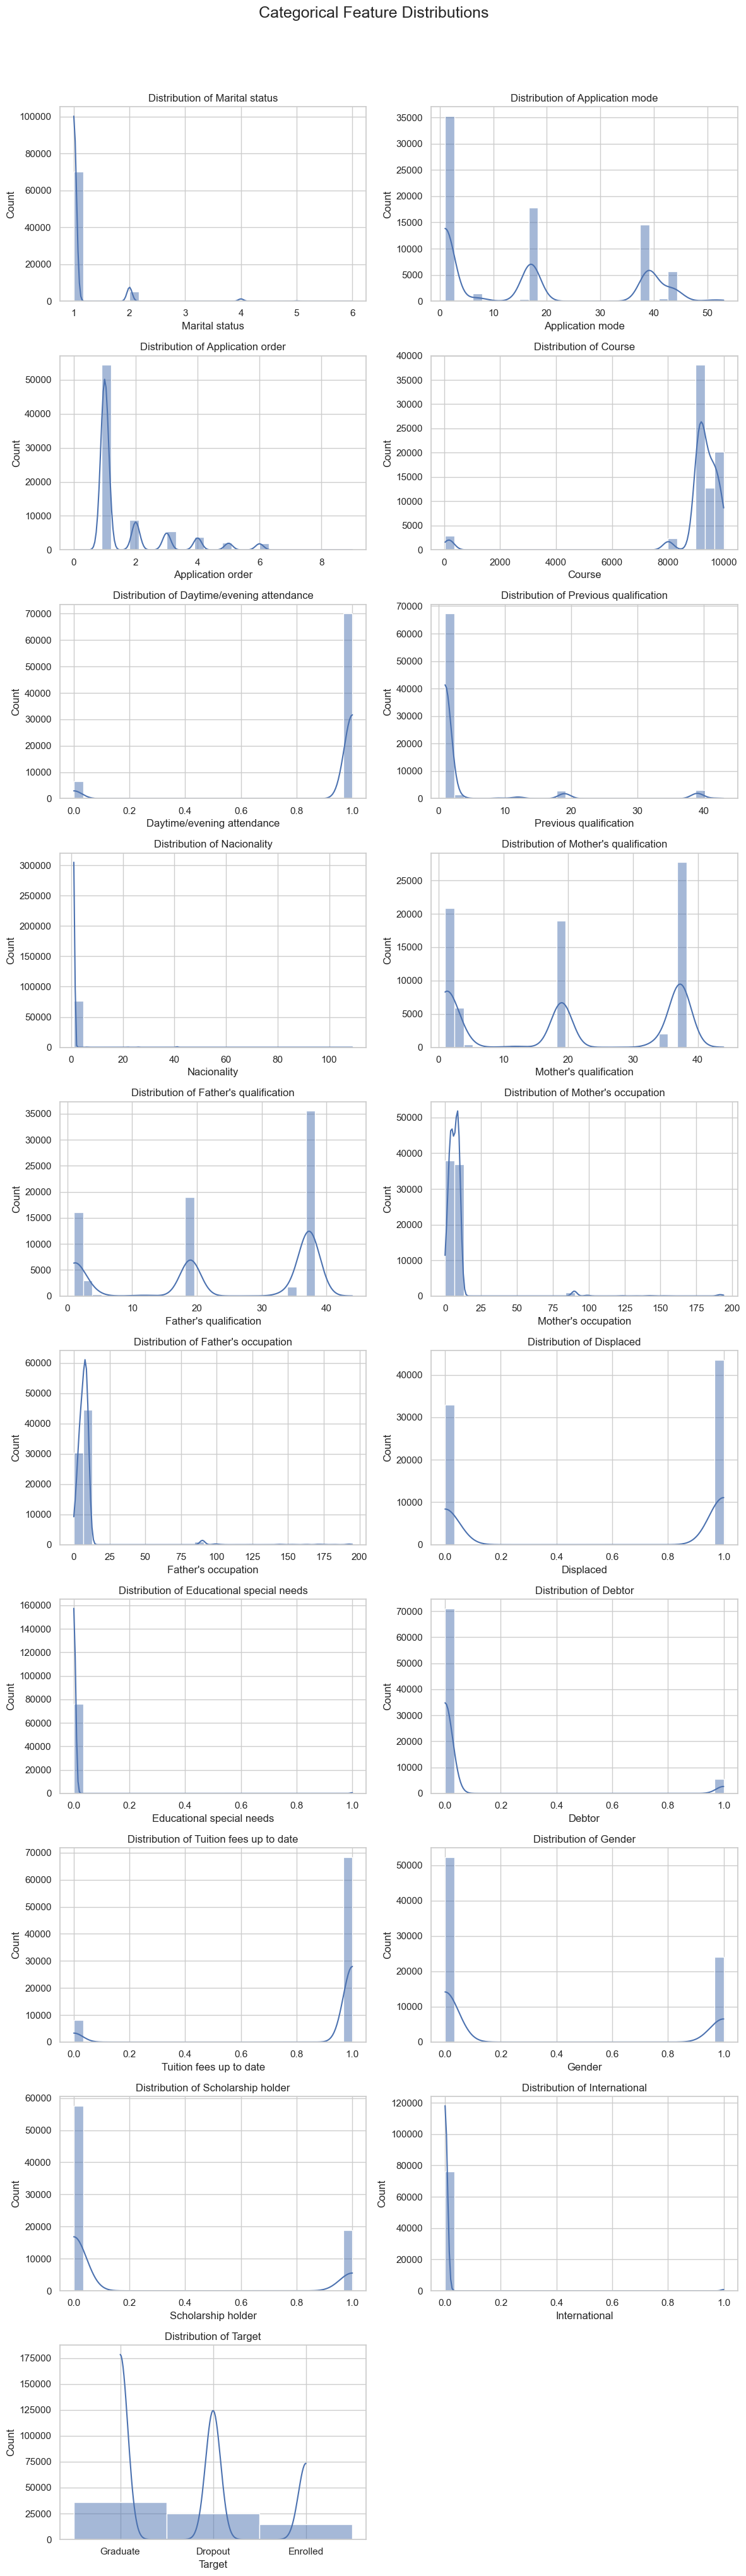

In [73]:
n_cols = 2
n_rows = math.ceil(len(categorical_vars) / n_cols)
plt.figure(figsize=(12, 4 * n_rows))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
fig.suptitle("Categorical Feature Distributions", fontsize=18, y=1.02)
axes = axes.flatten()
for i, col in enumerate(categorical_vars):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **Numerical feature distribution**

<Figure size 1200x3600 with 0 Axes>

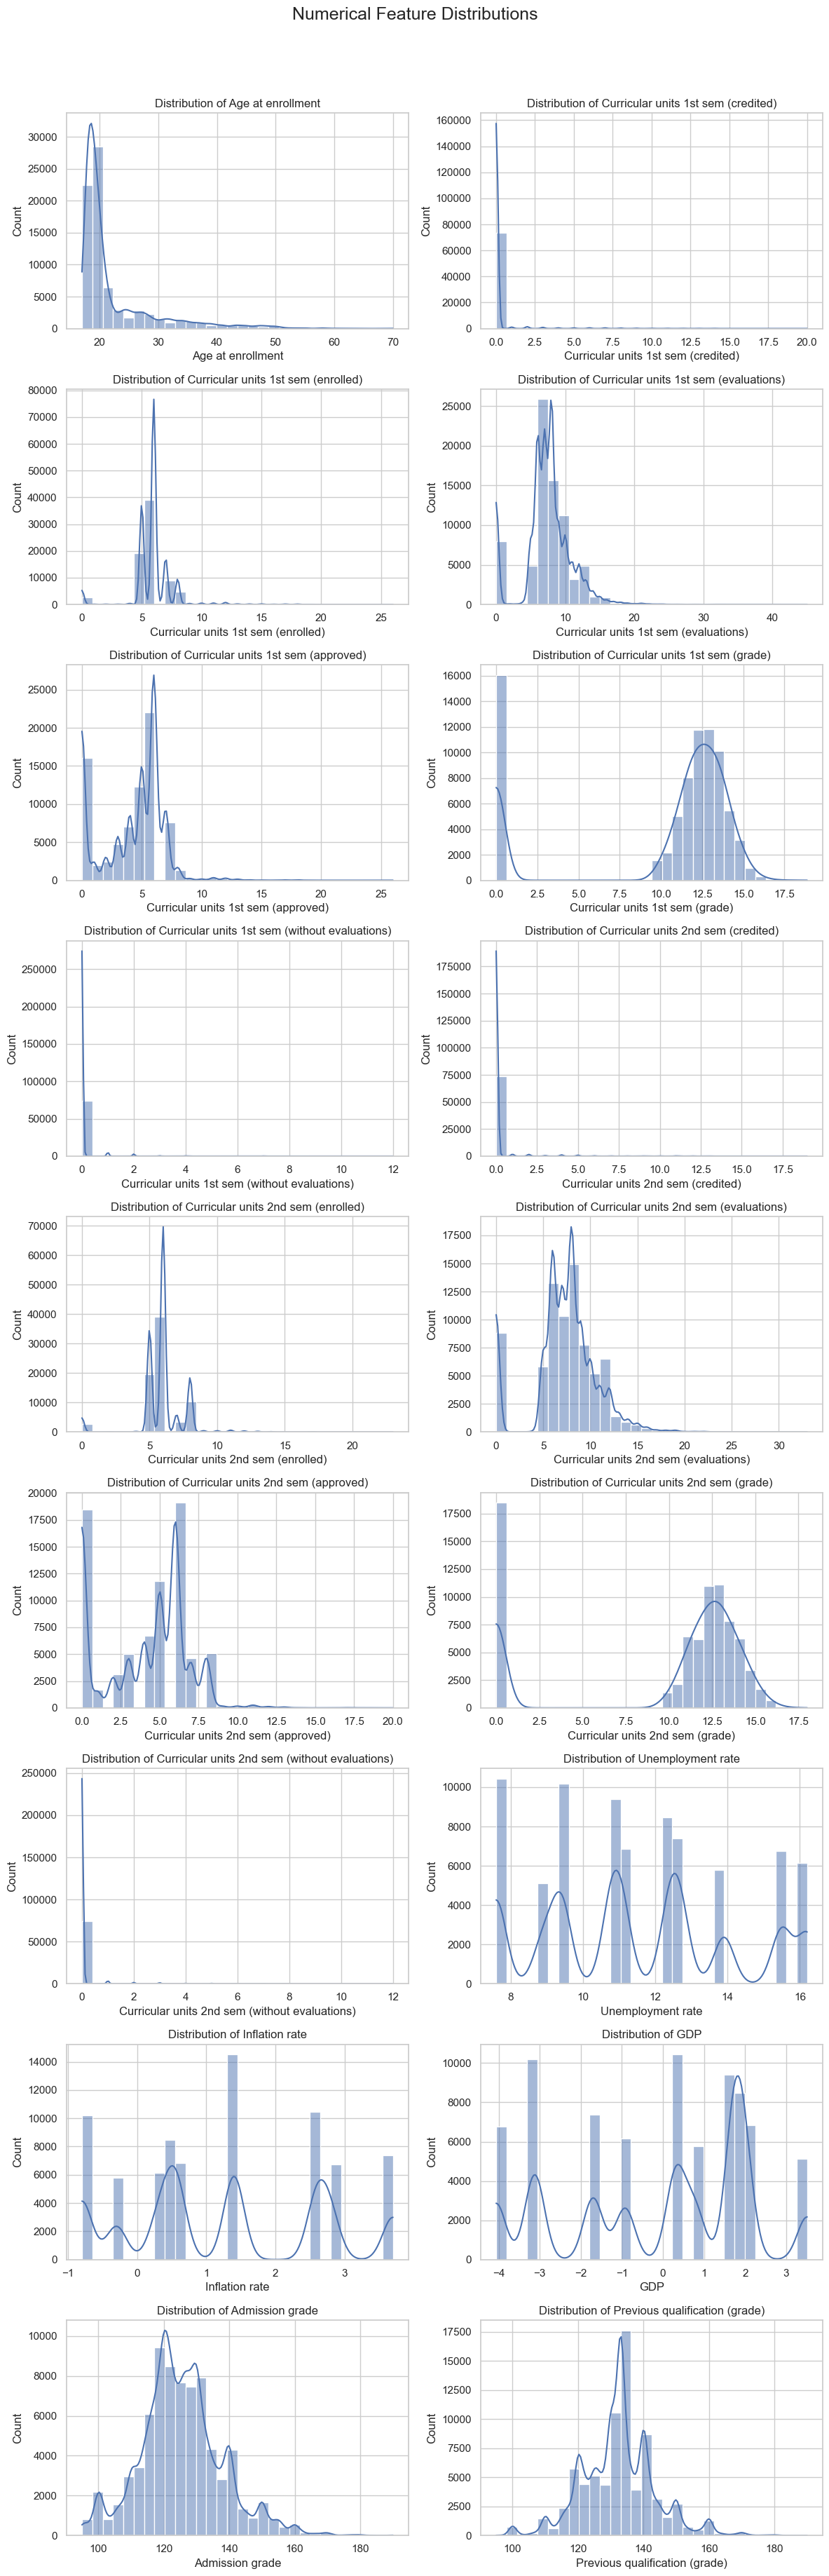

In [74]:
n_cols = 2
n_rows = math.ceil(len(numerical_vars) / n_cols)
plt.figure(figsize=(12, 4 * n_rows))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
fig.suptitle("Numerical Feature Distributions", fontsize=18, y=1.02)
axes = axes.flatten()
for i, col in enumerate(numerical_vars):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [75]:
# Detect outliers using the IQR method
numeric_cols = df.select_dtypes(include=[np.number]).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | 
              (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()

print("Number of outliers (per column):\n", outliers)

Number of outliers (per column):
 id                                                    0
Marital status                                     6329
Application mode                                      0
Application order                                  7895
Course                                             5371
Daytime/evening attendance                         6480
Previous qualification                             9335
Previous qualification (grade)                     1364
Nacionality                                         505
Mother's qualification                                0
Father's qualification                                0
Mother's occupation                                1660
Father's occupation                                1684
Admission grade                                    2577
Displaced                                             0
Educational special needs                           286
Debtor                                             5462
Tuition fees u

# **Outlier Detection Boxplots**

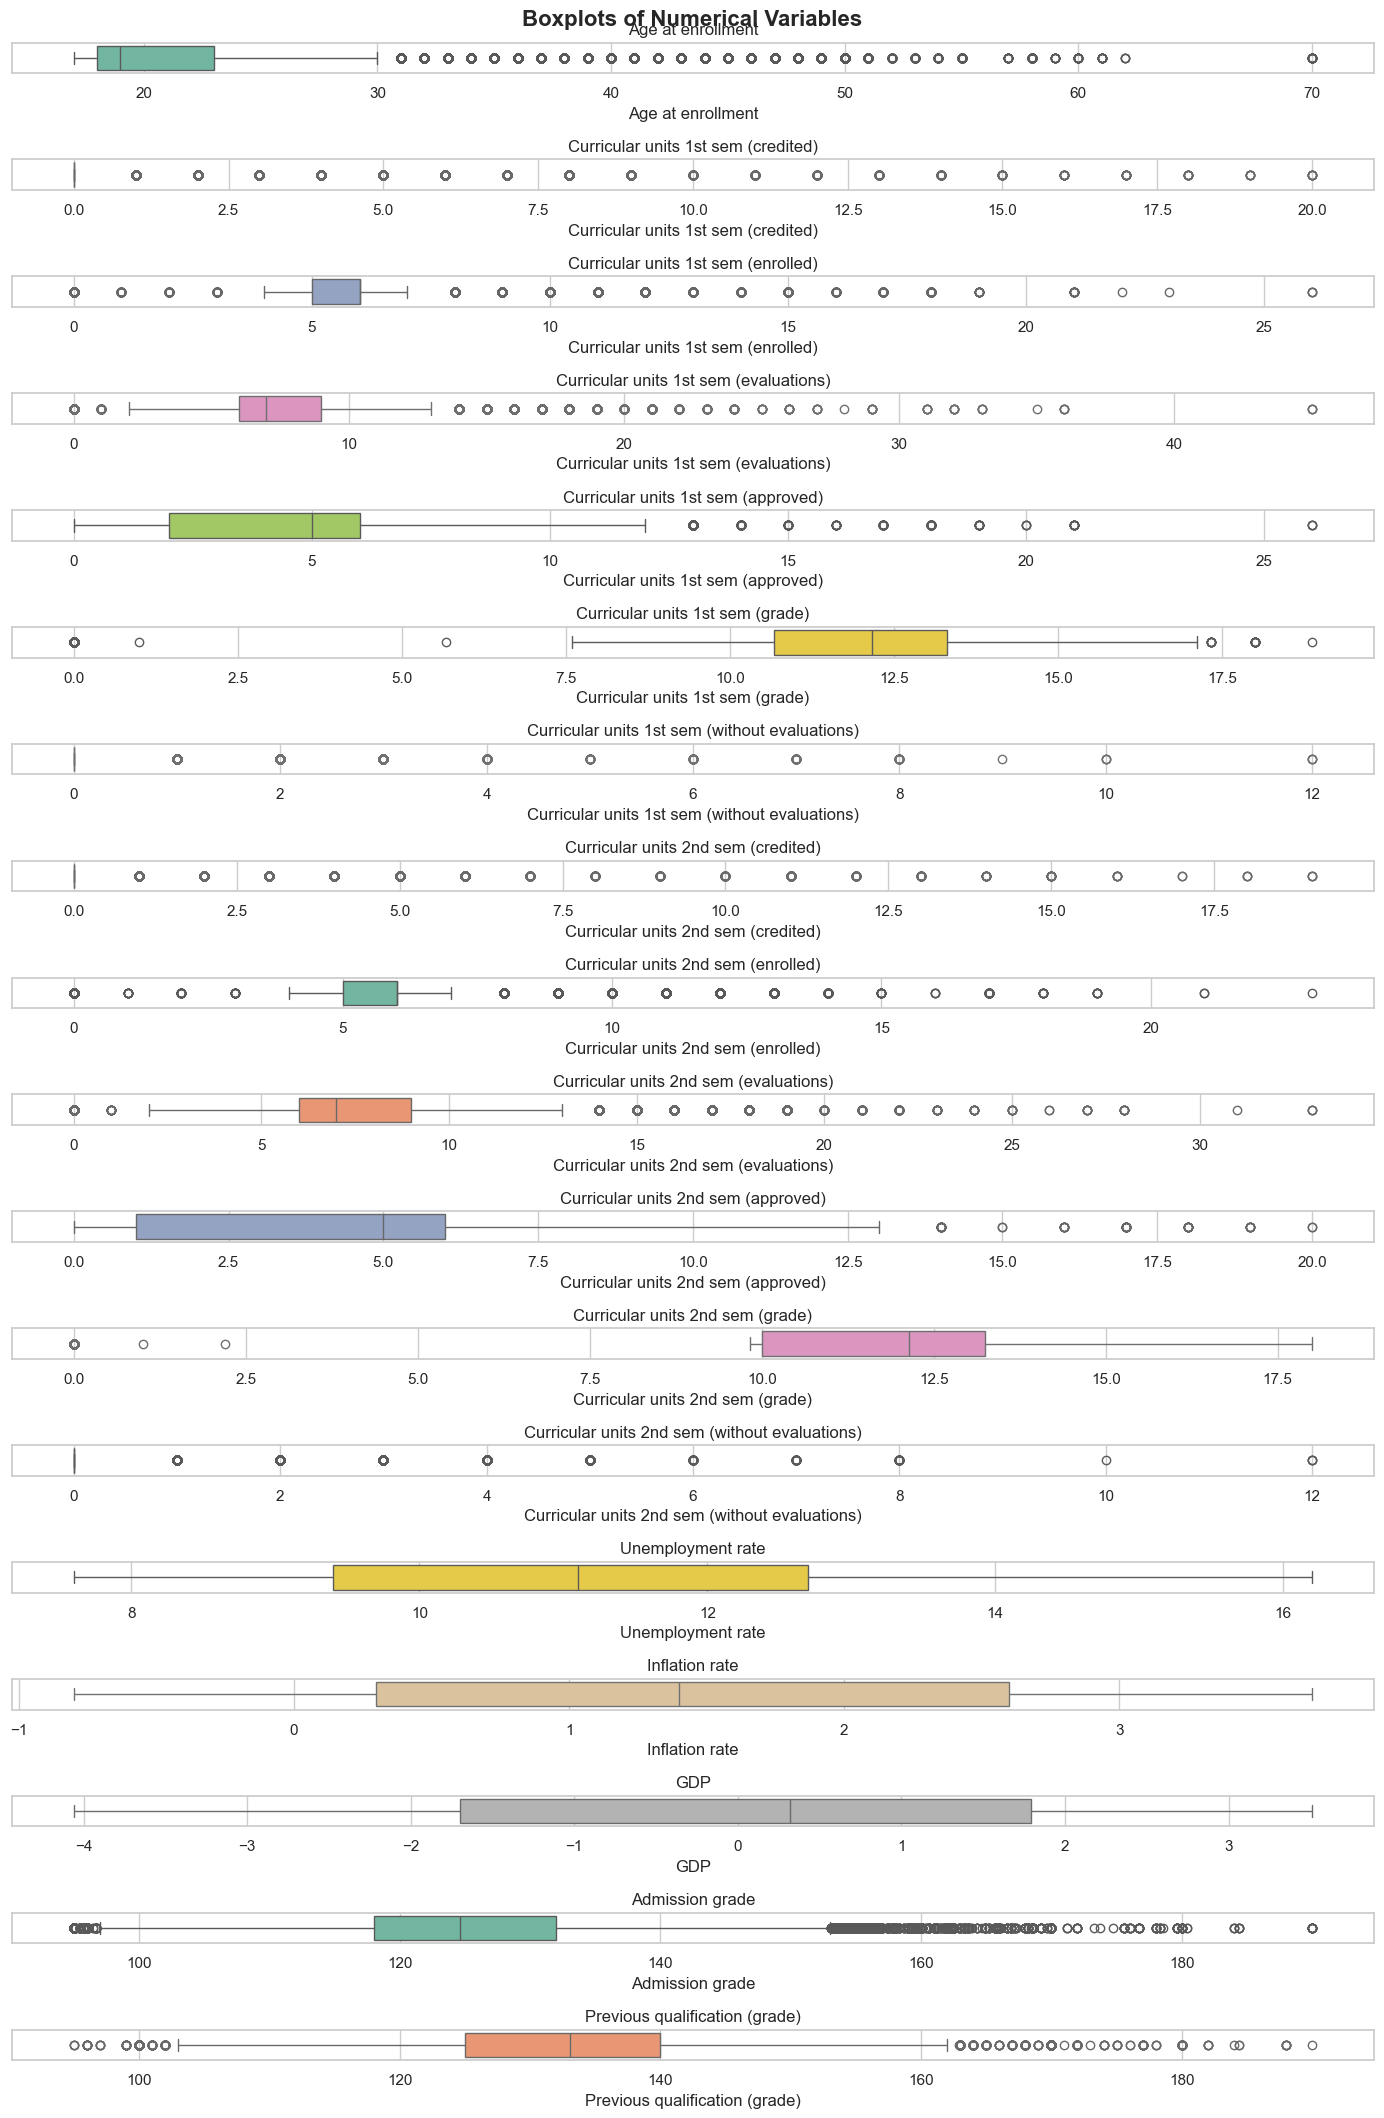

In [76]:
numeric_cols = [col for col in numerical_vars if col in df.columns]

palette = sns.color_palette("Set2", n_colors=len(numeric_cols))

n = len(numeric_cols)

plt.figure(figsize=(14, n * 1.2))
plt.suptitle("Boxplots of Numerical Variables", fontsize=16, fontweight='bold')

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n, 1, i)
    sns.boxplot(
        x=df[col],
        orient='h',
        color=palette[i - 1]
    )
    plt.title(col)
    plt.tight_layout()

plt.show()


In [77]:
def classify_columns_by_outliers(df, numerical_vars, outlier_threshold=0.05):
    """
    Classify numerical columns into high-outlier and low-outlier groups
    """
    numeric_cols = [col for col in numerical_vars if col in df.columns]

    # IQR calculation
    Q1 = df[numeric_cols].quantile(0.25)
    Q3 = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1

    # Count outliers for each column based on IQR rule
    outlier_counts = (
        (df[numeric_cols] < (Q1 - 1.5 * IQR)) |
        (df[numeric_cols] > (Q3 + 1.5 * IQR))
    ).sum()

    outlier_ratios = outlier_counts / len(df)

    # Classify based on threshold
    high_outlier_cols = outlier_ratios[outlier_ratios > outlier_threshold].index.tolist()
    low_outlier_cols = outlier_ratios[outlier_ratios <= outlier_threshold].index.tolist()

    return high_outlier_cols, low_outlier_cols, outlier_ratios


# Call the function for your data 
high_outlier_cols, low_outlier_cols, outlier_ratios = classify_columns_by_outliers(
    df=df,
    numerical_vars=numerical_vars,
    outlier_threshold=0.05
)

print("Sort columns based on outliers")

print(f"\nColumns with many outliers (>5%):\n{high_outlier_cols}")

print(f"\nColumns with few outliers (<=5%):\n{low_outlier_cols}")
print("\nOutlier ratios (sorted):")
print(outlier_ratios.sort_values(ascending=False))


Sort columns based on outliers

Columns with many outliers (>5%):
['Age at enrollment', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (grade)']

Columns with few outliers (<=5%):
['Curricular units 1st sem (credited)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Admission grade', 'Previous qualification (grade)']

Outlier ratios (sorted):
Curricular units 2nd sem (grade)                  0.241538
Curricular units 1st sem (grade)                  0.209872
Curricular units 2nd sem (enrolled)               0.188400
Curricular units 2nd sem (evaluations)            0.147077
Curricular units 1st sem 

In [88]:
def cap_outliers_iqr(df, cols):
    df_capped = df.copy()
    for col in cols:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # Cap
        df_capped[col] = np.where(df_capped[col] < lower, lower, df_capped[col])
        df_capped[col] = np.where(df_capped[col] > upper, upper, df_capped[col])
    return df_capped

df_capped = cap_outliers_iqr(df, high_outlier_cols)

print("Outliers in high-outlier columns have been capped using IQR method.")

Outliers in high-outlier columns have been capped using IQR method.


In [89]:
numeric_cols = [col for col in numerical_vars if col in df_capped.columns]

# IQR calculation
Q1 = df_capped[numeric_cols].quantile(0.25)
Q3 = df_capped[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Count outliers after capping
outliers_after = ((df_capped[numeric_cols] < (Q1 - 1.5 * IQR)) | 
                  (df_capped[numeric_cols] > (Q3 + 1.5 * IQR))).sum()

print("Number of outliers after capping:\n", outliers_after)


Number of outliers after capping:
 Age at enrollment                                    0
Curricular units 1st sem (credited)               3089
Curricular units 1st sem (enrolled)                  0
Curricular units 1st sem (evaluations)               0
Curricular units 1st sem (approved)                293
Curricular units 1st sem (grade)                     0
Curricular units 1st sem (without evaluations)    2449
Curricular units 2nd sem (credited)               2709
Curricular units 2nd sem (enrolled)                  0
Curricular units 2nd sem (evaluations)               0
Curricular units 2nd sem (approved)                 61
Curricular units 2nd sem (grade)                     0
Curricular units 2nd sem (without evaluations)    2146
Unemployment rate                                    0
Inflation rate                                       0
GDP                                                  0
Admission grade                                   2577
Previous qualification (grade)

In [90]:
df['Target'].value_counts(normalize=True)

Target
Graduate    0.474163
Dropout     0.330589
Enrolled    0.195248
Name: proportion, dtype: float64